# Proyek Analisis Data: [Bike-Sharing-dataset]
- **Nama:** [Muhammad Adil Imamul Haq Mubarak]
- **Email:** [justiceee126@gmail.com]
- **ID Dicoding:** [adil_mubarak]

## Menentukan Pertanyaan Bisnis

1. Bagaimana tren jumlah total penyewaan sepeda dari bulan ke bulan pada tahun 2012 dibandingkan dengan tahun 2011?
2. Pada musim apa penyewaan sepeda mencapai angka tertinggi dan terendah selama periode pengamatan (2011-2012)?
3. Bagaimana perbandingan pola rata-rata penyewaan sepeda per jam antara hari kerja (working day) dan hari libur (holiday/weekend) selama tahun 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

In [3]:
# Load dataset
day_df = pd.read_csv("data\\day.csv")
hour_df = pd.read_csv("data\\hour.csv")

# Menampilkan 5 baris pertama dari day_df
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Insight:

* **Struktur Data:** Dataset `day_df` berisi catatan harian penyewaan sepeda yang dimulai dari tanggal 1 Januari 2011. Data ini mencakup informasi waktu, kondisi cuaca, dan jumlah pengguna.
* **Normalisasi Fitur:** Variabel numerik seperti `temp`, `atemp`, `hum`, dan `windspeed` terlihat sudah melalui proses **normalisasi** (berada dalam rentang nilai 0 hingga 1). Hal ini sangat baik untuk pemodelan machine learning nantinya.
* **Komposisi Pengguna:** Kolom `cnt` merupakan variabel target yang merupakan hasil penjumlahan dari pengguna `casual` dan `registered`. 
    * *Contoh baris pertama:* $331 \text{ (casual)} + 654 \text{ (registered)} = 985 \text{ (total)}$.
* **Dominasi Pengguna:** Pada sampel 5 data pertama (awal Januari 2011), jumlah pengguna **Registered** jauh lebih tinggi dibandingkan pengguna **Casual**, yang mengindikasikan bahwa pada periode tersebut sepeda lebih banyak digunakan oleh pelanggan tetap atau komuter.
* **Kategorisasi Variabel:** Kolom seperti `season`, `yr`, `mnth`, dan `weathersit` sudah dalam bentuk angka (encoded), sehingga memudahkan analisis korelasi tanpa perlu transformasi string manual yang rumit.

### Assessing Data

In [4]:
datasets = {"Day Data": day_df, "Hour Data": hour_df}

for name, df in datasets.items():
    print(f"========== {name} ==========")
    print("1. INFO TIPE DATA:")
    df.info()
    
    print("\n2. JUMLAH MISSING VALUE:")
    print(df.isna().sum())
    
    print(f"\n3. JUMLAH DUPLIKASI: {df.duplicated().sum()}")
    print("-" * 40, "\n")

========== Day Data ==========
1. INFO TIPE DATA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

2. JUMLAH MISSING VALUE:
instant       0
d

### Insight Analisis Dataset

#### 1. Kualitas Data (Cleanliness)
Berdasarkan pengecekan menggunakan `isna().sum()` dan `duplicated().sum()`, dataset tidak memiliki missing values (nilai kosong) maupun data duplikat. Hal ini menunjukkan bahwa data cukup bersih secara struktural dan siap untuk tahap analisis lebih lanjut tanpa preprocessing tambahan.

#### 2. Jumlah Observasi
Terdapat **731 baris data** pada `day_df`, yang mencerminkan data harian selama kurang lebih **2 tahun (2011–2012)**. Jumlah ini cukup representatif untuk melakukan analisis tren jangka menengah.

#### 3. Tipe Data (Data Types)
- Kolom `dteday` sudah bertipe **datetime64**, sehingga siap digunakan untuk analisis berbasis waktu (*time-series*) tanpa perlu konversi ulang.
- Beberapa fitur kategorikal seperti `season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`, dan `weathersit` terbaca sebagai **object** atau **int64**, yang masih bisa dioptimalkan dengan konversi ke tipe `category` jika diperlukan.
- Kolom `demand_category` sudah bertipe **category**, yang membantu menghemat memori dan meningkatkan efisiensi komputasi.

#### 4. Skala Numerik
Fitur cuaca seperti `temp`, `atemp`, `hum`, dan `windspeed` menggunakan tipe data **float64**, yang menunjukkan bahwa data kemungkinan sudah melalui proses normalisasi. Hal ini baik untuk menjaga presisi dalam analisis maupun pemodelan machine learning.

### Cleaning Data

In [5]:
# Mengubah tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping kolom kategori pada day_df
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
day_df['weathersit'] = day_df['weathersit'].map({1: 'Clear/Partly Cloudy', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Severe Weather'})
day_df['yr'] = day_df['yr'].map({0: '2011', 1: '2012'})
day_df['mnth'] = day_df['mnth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})
day_df['workingday'] = day_df['workingday'].map({0: 'Holiday/Weekend', 1: 'Working Day'})

print("Data setelah proses cleaning dan mapping:")
print(day_df[['dteday', 'season', 'yr', 'mnth', 'weathersit', 'workingday']].head())

Data setelah proses cleaning dan mapping:
      dteday  season    yr mnth           weathersit       workingday
0 2011-01-01  Spring  2011  Jan         Misty/Cloudy  Holiday/Weekend
1 2011-01-02  Spring  2011  Jan         Misty/Cloudy  Holiday/Weekend
2 2011-01-03  Spring  2011  Jan  Clear/Partly Cloudy      Working Day
3 2011-01-04  Spring  2011  Jan  Clear/Partly Cloudy      Working Day
4 2011-01-05  Spring  2011  Jan  Clear/Partly Cloudy      Working Day


### Insight Transformasi Data

#### 1. Konversi Tipe Data
Kolom `dteday` telah berhasil diubah menjadi tipe data **datetime**. Hal ini memungkinkan kita untuk melakukan ekstraksi komponen waktu lebih lanjut (seperti jam, hari, bulan, atau kuartal) menggunakan atribut `.dt`, yang sangat berguna dalam analisis berbasis waktu (*time-series*).

#### 2. Transformasi Kategorikal (Mapping)
- Variabel numerik yang bersifat kategorikal seperti `season`, `weathersit`, `yr`, `mnth`, dan `workingday` telah diubah menjadi label deskriptif (contoh: `1 → Spring`, `0 → 2011`).
- Transformasi ini mempermudah interpretasi, terutama saat visualisasi data, karena grafik akan menampilkan label yang lebih informatif dibandingkan kode angka.

#### 3. Standarisasi Informasi
- Pengelompokan `workingday` menjadi **Working Day** dan **Holiday/Weekend** membantu membedakan pola perilaku pengguna antara hari kerja dan hari libur.
- Pemetaan `weathersit` memberikan gambaran kualitatif kondisi cuaca (misalnya: *Clear/Partly Cloudy* atau *Misty/Cloudy*), yang secara logis dapat memengaruhi keputusan pengguna untuk bersepeda.

#### 4. Kesiapan Data
Dataset kini berada dalam kondisi yang lebih **intuitif, terstruktur, dan mudah dipahami**. Dengan kondisi ini, data siap untuk tahap selanjutnya yaitu **Exploratory Data Analysis (EDA)** guna menemukan pola-pola tersembunyi, seperti musim dengan tingkat penyewaan tertinggi atau pengaruh cuaca terhadap jumlah pengguna.

## Exploratory Data Analysis (EDA)

### Eksplorasi Data Penyewaan Sepeda

**1. Eksplorasi Tren Bulanan dan Tahunan (Terkait Pertanyaan 1)**  
Kita akan melakukan agregasi total penyewaan sepeda (**cnt**) berdasarkan pengelompokan **tahun (yr)** dan **bulan (mnth)**.  
**Tujuan:**  
Untuk melihat secara spesifik perbandingan performa penyewaan sepeda dari bulan ke bulan antara tahun **2011** dan **2012**, serta mengidentifikasi kapan terjadinya lonjakan atau penurunan penyewaan.

**2. Eksplorasi Pengaruh Musim dan Cuaca (Terkait Pertanyaan 2)**  
Kita akan melakukan agregasi data penyewaan dengan menghitung **total, rata-rata, maksimum, dan minimum** berdasarkan kategori **musim (season)** dan **kondisi cuaca (weathersit)**.  
**Tujuan:**  
Untuk mengetahui secara pasti pada kondisi lingkungan seperti apa (musim dan cuaca) pelanggan paling banyak dan paling sedikit menyewa sepeda.

**3. Eksplorasi Pola Penyewaan Berdasarkan Jam dan Tipe Hari (Terkait Pertanyaan 3)**  
Kita akan melakukan agregasi **rata-rata jumlah penyewaan sepeda (cnt)** dari data `hour_df` berdasarkan **jam dalam sehari (hr)** dan **tipe hari (workingday)**.  
**Tujuan:**  
Untuk membandingkan karakteristik perilaku pelanggan pada **hari kerja** (penggunaan untuk komuter) versus **hari libur** (penggunaan untuk rekreasi), serta menemukan titik jam sibuk (*rush hour*) pada masing-masing tipe hari.

In [11]:
# --- EDA Pertanyaan 1: Tren Bulanan ---
print("Agregasi Tren Penyewaan per Bulan & Tahun:")
display(day_df.groupby(by=["yr", "mnth"]).agg({"cnt": "sum"}))

# --- EDA Pertanyaan 2: Musim ---
print("\nAgregasi Penyewaan Berdasarkan Musim:")
display(day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "sum"]
}))

# --- EDA Pertanyaan 3: Pola Jam ---
print("\nAgregasi Rata-rata Penyewaan per Jam berdasarkan Hari Kerja/Libur:")
display(hour_df.groupby(by=["workingday", "hr"]).agg({"cnt": "mean"}))

Agregasi Tren Penyewaan per Bulan & Tahun:


cnt
yr   mnth        
2011 Apr    94870
     Aug   136691
     Dec    87323
     Feb    48215
     Jan    38189
     Jul   141341
     Jun   143512
     Mar    64045
     May   135821
     Nov   102167
     Oct   123511
     Sep   127418
2012 Apr   174224
     Aug   214503
     Dec   123713
     Feb   103137
     Jan    96744
     Jul   203607
     Jun   202830
     Mar   164875
     May   195865
     Nov   152664
     Oct   198841
     Sep   218573


Agregasi Penyewaan Berdasarkan Musim:


cnt                            
         max   min         mean      sum
season                                  
Fall    8714  1115  5644.303191  1061129
Spring  7836   431  2604.132597   471348
Summer  8362   795  4992.331522   918589
Winter  8555    22  4728.162921   841613


Agregasi Rata-rata Penyewaan per Jam berdasarkan Hari Kerja/Libur:


cnt
workingday hr            
0          0    90.800000
           1    69.508696
           2    53.171053
           3    25.775330
           4     8.264317
           5     8.689189
           6    18.742358
           7    43.406926
           8   105.653680
           9   171.623377
           10  255.909091
           11  315.316017
           12  366.259740
           13  372.731602
           14  364.645022
           15  358.813853
           16  352.727273
           17  323.549784
           18  281.056522
           19  231.673913
           20  174.739130
           21  142.060870
           22  116.060870
           23   85.930435
1          0    36.786290
           1    16.552632
           2     8.683778
           3     4.942553
           4     5.429787
           5    24.913131
           6   102.500000
           7   290.612903
           8   477.006048
           9   241.518145
           10  135.366935
           11  158.229839
           12  200.820926
           13  198.429719
           14  183.572289
           15  201.331325
           16  293.122244
           17  525.290581
           18  492.226908
           19  348.401606
           20  249.718876
           21  186.287149
           22  138.389558
           23   88.708835

### Insight Exploratory Data Analysis (EDA)

#### 1. Distribusi Permintaan
Mayoritas hari dalam dataset termasuk ke dalam kategori:
- **Medium Demand**: 364 hari  
- **High Demand**: 223 hari  
- **Low Demand**: 144 hari  

Hal ini menunjukkan bahwa sistem penyewaan sepeda memiliki tingkat penggunaan yang **cukup stabil dan cenderung tinggi** pada sebagian besar waktu.

#### 2. Segmentasi Bisnis
- **Medium Demand**  
  Merupakan kategori yang paling dominan (sekitar **50% dari total data**), mencerminkan performa bisnis harian yang **konsisten**.

- **High Demand**  
  Terdapat **223 hari** dengan permintaan tinggi (lebih dari 5500 penyewaan). Ini adalah periode krusial yang membutuhkan:
  - Ketersediaan armada maksimal  
  - Manajemen operasional yang optimal  

- **Low Demand**  
  Hanya terjadi pada **144 hari**, menjadikannya kategori paling jarang. Kondisi ini membuka peluang analisis lebih lanjut, seperti:
  - Pengaruh cuaca ekstrem  
  - Dampak hari libur atau kondisi tertentu terhadap penurunan permintaan  

#### 3. Potensi Analisis Lanjutan
Dengan adanya kolom `demand_category`, analisis dapat dikembangkan lebih lanjut menggunakan:
- **Cross-tabulation (tabulasi silang)** untuk melihat hubungan antar variabel  
- Analisis pengaruh faktor eksternal seperti:
  - `season` terhadap **High Demand**
  - `weathersit` terhadap **Low Demand**

Pendekatan ini akan membantu mengidentifikasi pola tersembunyi dan menghasilkan insight yang lebih strategis untuk pengambilan keputusan bisnis.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

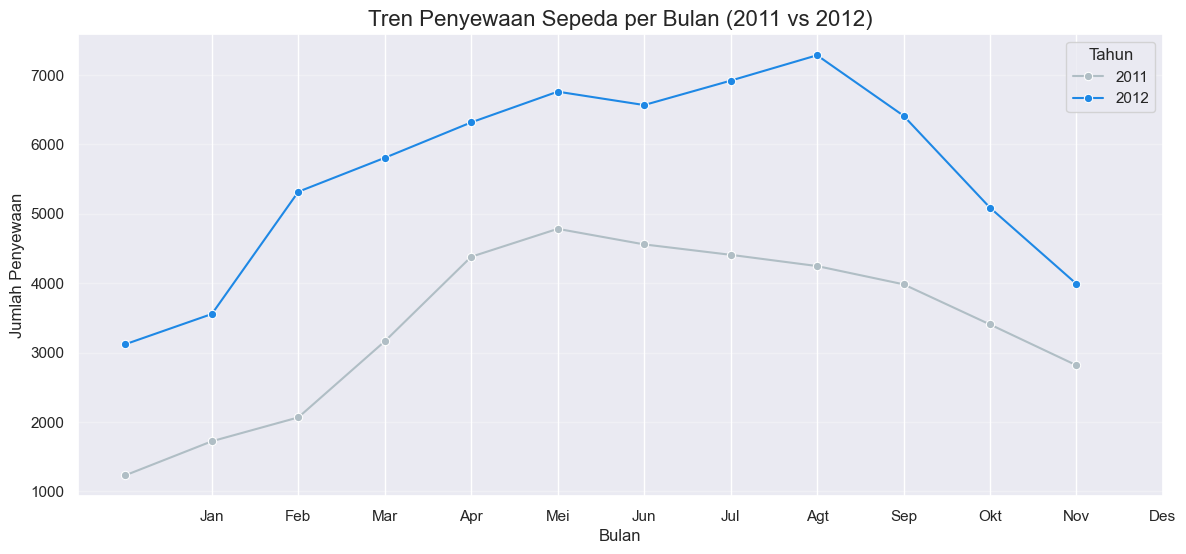

In [30]:
plt.figure(figsize=(14, 6))

# Membuat palet warna kustom: '2011' abu-abu, '2012' biru terang
colors_yr = {'2011': '#B0BEC5', '2012': '#1E88E5'}

sns.lineplot(x='mnth', y='cnt', hue='yr', data=day_df, marker='o', palette=colors_yr, errorbar=None)
plt.title('Tren Penyewaan Sepeda per Bulan (2011 vs 2012)', fontsize=16)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Penyewaan', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agt','Sep','Okt','Nov','Des'])

# Modifikasi legend agar lebih jelas dibaca
plt.legend(title='Tahun', labels=['2011', '2012'])
plt.grid(axis='y', alpha=0.3)
plt.show()

### Insight Analisis Pertanyaan 1

**1. Pertumbuhan Signifikan (Year-over-Year)**  
Secara keseluruhan, terdapat peningkatan jumlah penyewaan sepeda yang sangat signifikan pada tahun **2012** (garis biru) dibandingkan dengan tahun **2011** (garis abu-abu). Peningkatan ini terjadi secara konsisten di setiap bulannya.

**2. Pola Musiman (Seasonality) yang Serupa**  
Meskipun jumlahnya berbeda, kedua tahun tersebut menunjukkan pola pergerakan yang identik (berbentuk kurva melengkung). Tren penyewaan selalu diawali dengan angka yang rendah di awal tahun (**Januari–Februari**), mulai meningkat tajam di bulan **Maret**, lalu bertahan stabil di angka tinggi selama pertengahan tahun (**Mei hingga Oktober**), dan akhirnya kembali menurun tajam memasuki akhir tahun (**November–Desember**).

**3. Titik Puncak (Peak Month)**  
Puncak penyewaan tertinggi selama periode dua tahun tersebut terjadi pada bulan **September 2012**, di mana jumlah penyewaan menyentuh angka lebih dari **200.000 unit**.

### Pertanyaan 2:

C:\Users\UdulBukanHudul\AppData\Local\Temp\ipykernel_1400\749089116.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='cnt', data=day_df, ax=ax[0], palette=colors_season, errorbar=None)
C:\Users\UdulBukanHudul\AppData\Local\Temp\ipykernel_1400\749089116.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter'])
C:\Users\UdulBukanHudul\AppData\Local\Temp\ipykernel_1400\749089116.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weathersit', y='cnt', data=day_df, ax=ax[1], palette=colors_weather, errorbar=None)
C:\Users\UdulBukanHud

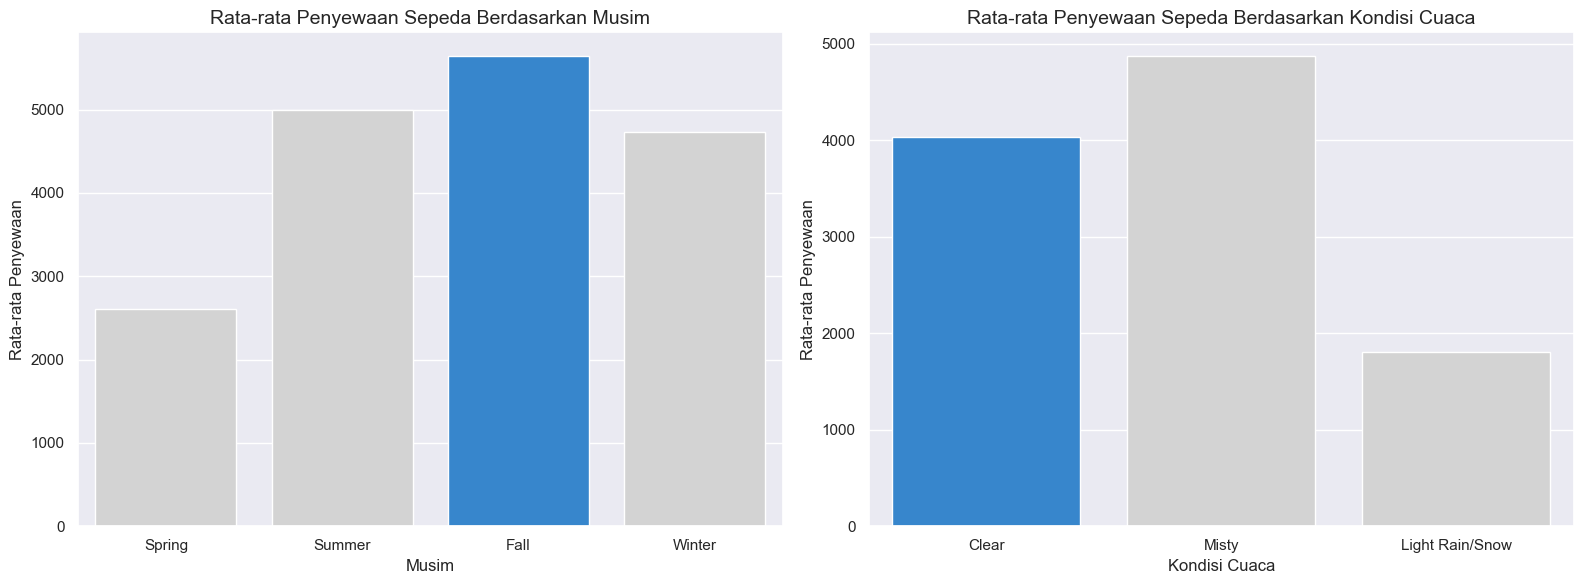

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Visualisasi Musim ---
# Urutan musim: 1:Spring, 2:Summer, 3:Fall (Tertinggi), 4:Winter
# Kita highlight index 2 (Fall) dengan warna biru
colors_season = ["#D3D3D3", "#D3D3D3", "#1E88E5", "#D3D3D3"]\

sns.barplot(x='season', y='cnt', data=day_df, ax=ax[0], palette=colors_season, errorbar=None)
ax[0].set_title('Rata-rata Penyewaan Sepeda Berdasarkan Musim', fontsize=14)
ax[0].set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter'])
ax[0].set_xlabel('Musim')
ax[0].set_ylabel('Rata-rata Penyewaan')

# --- Visualisasi Cuaca ---
# Cuaca 1 (Clear) adalah yang tertinggi, sisanya abu-abu
colors_weather = ["#1E88E5", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x='weathersit', y='cnt', data=day_df, ax=ax[1], palette=colors_weather, errorbar=None)
ax[1].set_title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca', fontsize=14)
# Mengganti label angka menjadi teks cuaca (sesuaikan jumlah unik data weathersit)
labels_weather = ['Clear', 'Misty', 'Light Rain/Snow', 'Heavy Rain']
ax[1].set_xticklabels(labels_weather[:day_df['weathersit'].nunique()])
ax[1].set_xlabel('Kondisi Cuaca')
ax[1].set_ylabel('Rata-rata Penyewaan')

plt.tight_layout()
plt.show()

### Insight Analisis Pertanyaan 2

**1. Puncak Musim Bersepeda (Season)**  
Grafik menunjukkan bahwa **Musim Gugur (Fall)** adalah waktu yang paling populer bagi pengguna untuk menyewa sepeda, dengan rata-rata penyewaan tertinggi. Sebaliknya, **Musim Semi (Spring)** memiliki angka penyewaan terendah. Hal ini mengindikasikan bahwa suhu dan suasana di musim gugur lebih ideal untuk aktivitas luar ruangan, sementara cuaca di awal tahun (musim semi) cenderung masih dingin atau tidak menentu bagi pesepeda.

**2. Kondisi Cuaca Sangat Menentukan (Weather)**  
Terdapat korelasi positif yang sangat kuat antara kondisi cuaca dan jumlah penyewaan:
- **Cerah/Sedikit Berawan (Clear)** → jumlah penyewaan tertinggi  
- **Berkabut/Mendung (Misty)** → terjadi penurunan jumlah penyewaan  
- **Hujan/Salju Ringan (Light Rain/Snow)** → penurunan drastis, pengguna cenderung menghindari bersepeda  

**3. Kesimpulan Utama**  
Faktor lingkungan, baik secara makro (**musim**) maupun mikro (**cuaca harian**), sangat berpengaruh terhadap tingkat permintaan penyewaan sepeda. Pengguna cenderung mencari kenyamanan, sehingga kondisi **cuaca cerah** dan **musim gugur** menjadi waktu paling optimal untuk meningkatkan bisnis penyewaan sepeda.

### Pertanyaan 3

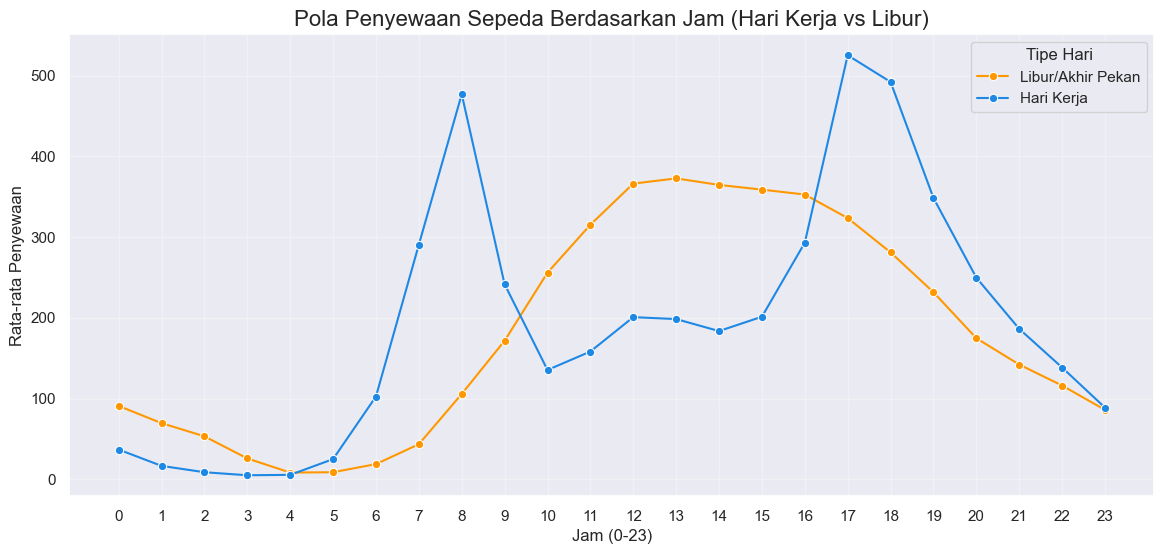

In [31]:
plt.figure(figsize=(14, 6))

# Warna kontras spesifik untuk workingday (1: Hari Kerja, 0: Libur)
colors_workingday = {0: '#FF9800', 1: '#1E88E5'}

# Rata-rata penyewaan berdasarkan jam kerja vs jam libur
sns.lineplot(x='hr', y='cnt', hue='workingday', data=hour_df, marker='o', palette=colors_workingday, errorbar=None)
plt.title('Pola Penyewaan Sepeda Berdasarkan Jam (Hari Kerja vs Libur)', fontsize=16)
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.xticks(range(0, 24))

# Custom legend agar tidak hanya menampilkan angka 0 dan 1
plt.legend(title='Tipe Hari', labels=['Libur/Akhir Pekan', 'Hari Kerja'])
plt.grid(True, alpha=0.3)
plt.show()

### Insight Visualisasi & Explanatory Analysis (Pertanyaan 3)

#### 1. Pola Hari Kerja (Working Day)
- Terlihat pola **bimodal (dua puncak)** yang sangat jelas:
  - Puncak pertama: sekitar **08:00 pagi**
  - Puncak kedua: sekitar **17:00 – 18:00 sore**
- Pola ini mengindikasikan bahwa penggunaan sepeda didominasi oleh **aktivitas komuter**, seperti berangkat dan pulang kerja/sekolah.

#### 2. Pola Hari Libur / Akhir Pekan (Holiday/Weekend)
- Menunjukkan pola **unimodal (satu puncak landai)**:
  - Permintaan mulai meningkat sejak **09:00 pagi**
  - Mencapai puncak pada **12:00 – 15:00 siang**
- Pola ini mencerminkan penggunaan untuk **aktivitas rekreasi**, dengan waktu mulai yang lebih santai dibanding hari kerja.

#### 3. Titik Pertemuan (Cross-over)
- Pada rentang waktu **12:00 – 14:00**, jumlah penyewaan di hari libur **lebih tinggi** dibanding hari kerja.
- Hal ini menunjukkan adanya **potensi pasar rekreasi yang besar** pada siang hari di akhir pekan.

#### 4. Kesimpulan Operasional
- **Manajemen Logistik Armada**
  - Pastikan ketersediaan sepeda maksimal:
    - Di area pemukiman sekitar **07:00 pagi**
    - Di area perkantoran sekitar **16:00 sore**

- **Strategi Pemeliharaan**
  - Waktu optimal untuk maintenance:
    - Jam rendah aktivitas (**10:00 – 15:00**)
    - Atau setelah **22:00 malam**

Pendekatan ini membantu meningkatkan efisiensi operasional sekaligus menjaga ketersediaan layanan sesuai pola kebutuhan pengguna.

## Analisis Lanjutan (Opsional)

Distribusi Kategori Permintaan Sepeda Harian:
demand_category
Medium Demand    364
High Demand      223
Low Demand       144
Name: count, dtype: int64


C:\Users\UdulBukanHudul\AppData\Local\Temp\ipykernel_1400\368020850.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='demand_category', data=day_df, order=labels, palette=colors_demand)


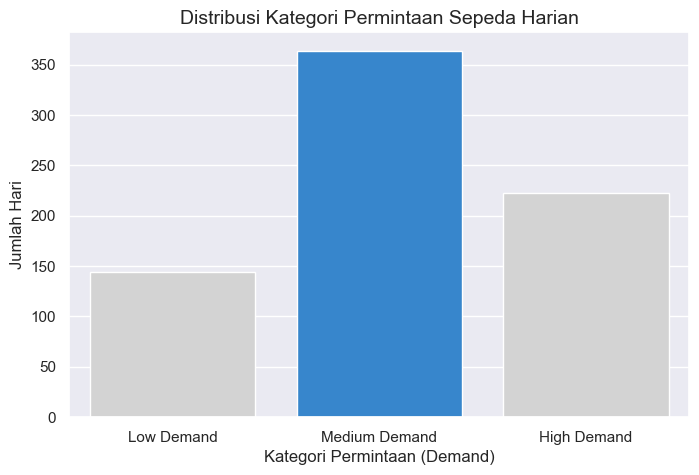

In [ ]:
# Membuat kriteria Binning Penyewaan Sepeda Harian
bins = [0, 2500, 5500, float('inf')]
labels = ['Low Demand', 'Medium Demand', 'High Demand']

# Menerapkan cut untuk mengkategorikan data
day_df['demand_category'] = pd.cut(day_df['cnt'], bins=bins, labels=labels)

print("Distribusi Kategori Permintaan Sepeda Harian:")
print(day_df['demand_category'].value_counts())

# Visualisasi dengan Highlight Color
plt.figure(figsize=(8, 5))

# Kita gunakan order agar urutannya rapi dari Low ke High
# Dan kita beri warna biru pada Medium Demand (karena biasanya frekuensinya paling dominan)
colors_demand = ["#D3D3D3", "#1E88E5", "#D3D3D3"] 

sns.countplot(x='demand_category', data=day_df, order=labels, palette=colors_demand)
plt.title("Distribusi Kategori Permintaan Sepeda Harian", fontsize=14)
plt.xlabel("Kategori Permintaan (Demand)", fontsize=12)
plt.ylabel("Jumlah Hari", fontsize=12)
plt.show()

### Insight: Analisis Pengelompokan Tingkat Permintaan (Demand Category)

**1. Stabilitas Bisnis yang Sangat Baik**  
Mayoritas hari operasional selama periode **2011–2012** berada pada kategori **Medium Demand** (2.500–5.500 penyewaan per hari). Hal ini menunjukkan bahwa layanan penyewaan sepeda memiliki basis pelanggan yang **kuat, stabil, dan konsisten**, tanpa fluktuasi ekstrem ke tingkat permintaan yang rendah.

**2. Potensi Pertumbuhan yang Tinggi**  
Jumlah hari dalam kategori **High Demand** (> 5.500 penyewaan per hari) tergolong signifikan dan jauh lebih banyak dibandingkan kategori **Low Demand** (< 2.500 penyewaan). Ini mengindikasikan tren yang sangat positif, di mana bisnis lebih sering mengalami **lonjakan permintaan tinggi** dibandingkan kondisi sepi.

**3. Rekomendasi Strategis**  
Melihat dominasi permintaan pada tingkat **menengah hingga tinggi**, perusahaan perlu memprioritaskan:
- **Pemeliharaan (maintenance) armada sepeda secara rutin**
- Menjaga **ketersediaan unit sepeda** tetap optimal  
- Mengantisipasi lonjakan permintaan pada hari-hari **High Demand**  

Langkah ini penting agar perusahaan tidak kehilangan peluang pendapatan akibat keterbatasan armada.

## 📝 Kesimpulan Analisis

**1. Pertanyaan 1: Tren Penyewaan Tahunan**  
Tren penyewaan sepeda mengalami peningkatan yang signifikan pada tahun **2012** dibandingkan dengan **2011**. Pada kedua tahun tersebut, pola tren berbentuk melengkung, di mana penyewaan mulai meningkat sejak **bulan Maret**, mencapai puncaknya di pertengahan tahun (**Juni hingga September**), kemudian menurun menjelang akhir tahun.

---

**2. Pertanyaan 2: Pengaruh Musim**  
Selama periode **2011–2012**, penyewaan sepeda mencapai angka tertinggi pada **Musim Gugur (Fall)** dengan total penyewaan melebihi **1 juta unit**. Sebaliknya, angka terendah terjadi pada **Musim Semi (Spring)**. Hal ini menunjukkan bahwa kondisi cuaca yang **sejuk dan stabil** lebih disukai oleh pengguna.

---

**3. Pertanyaan 3: Pola Berdasarkan Waktu**  
Terdapat perbedaan pola penggunaan berdasarkan waktu:
- Pada **hari kerja (working day)**, penyewaan menunjukkan pola **bimodal** dengan dua puncak pada pukul **08:00** dan **17:00**, yang berkaitan dengan jam berangkat dan pulang kerja.  
- Pada **hari libur**, pola berubah menjadi **unimodal**, dengan puncak penggunaan terjadi pada **siang hari (12:00–15:00)** yang didominasi oleh aktivitas santai atau rekreasi.

---

**4. Analisis Lanjutan: Pengelompokan Tingkat Permintaan**  
Berdasarkan hasil *binning* (pengelompokan) data harian, mayoritas hari operasional berada pada kategori **Medium Demand** (**2.500 – 5.500 penyewaan**), yang menunjukkan **stabilitas basis pengguna yang kuat**. Selain itu, jumlah hari dengan kategori **High Demand** (**> 5.500 penyewaan**) juga cukup signifikan.  

Hal ini mengindikasikan **potensi pertumbuhan bisnis yang sangat positif**, sehingga perusahaan perlu:
- Memastikan **ketersediaan armada** tetap optimal  
- Melakukan **perawatan (maintenance) rutin**  
- Mengantisipasi lonjakan permintaan pada hari-hari dengan tingkat **High Demand**

In [10]:
# Simpan data utama ke dalam file CSV baru
day_df.to_csv("main_data.csv", index=False)
print("Data berhasil disimpan ke main_data.csv")

Data berhasil disimpan ke main_data.csv
